## Analisis Climatico con OpenWeather
Extraer información climática contenida en la siguiente API y generar al menos un gráfico o tabla con estos datos.

In [ ]:
# importacion de librerias
import requests as request
import matplotlib.pyplot as plt
#Peticion para acceder a la API
url = "https://api.openweathermap.org/data/2.5/weather?q=London,uk&APPID=54bf82adf3db85f9ffc7a56a0a0bef15"

respuesta = request.get(url, timeout = 5)
datos = respuesta.json() #Permite leer los datos de la API
print(datos)

{'coord': {'lon': -0.1257, 'lat': 51.5085}, 'weather': [{'id': 804, 'main': 'Clouds', 'description': 'overcast clouds', 'icon': '04d'}], 'base': 'stations', 'main': {'temp': 285.17, 'feels_like': 283.84, 'temp_min': 283.98, 'temp_max': 285.94, 'pressure': 1012, 'humidity': 54, 'sea_level': 1012, 'grnd_level': 1008}, 'visibility': 10000, 'wind': {'speed': 4.12, 'deg': 0}, 'clouds': {'all': 88}, 'dt': 1778517184, 'sys': {'type': 2, 'id': 2075535, 'country': 'GB', 'sunrise': 1778472907, 'sunset': 1778528323}, 'timezone': 3600, 'id': 2643743, 'name': 'London', 'cod': 200}


In [7]:
print(datos.keys()) #Se revisan cuales son las llaves primarias

dict_keys(['coord', 'weather', 'base', 'main', 'visibility', 'wind', 'clouds', 'dt', 'sys', 'timezone', 'id', 'name', 'cod'])


In [8]:
#Se decide trabajar con la llave "main" y graficar las diferentes temperaturas
main = datos.get("main", {})
print(main.keys())

dict_keys(['temp', 'feels_like', 'temp_min', 'temp_max', 'pressure', 'humidity', 'sea_level', 'grnd_level'])


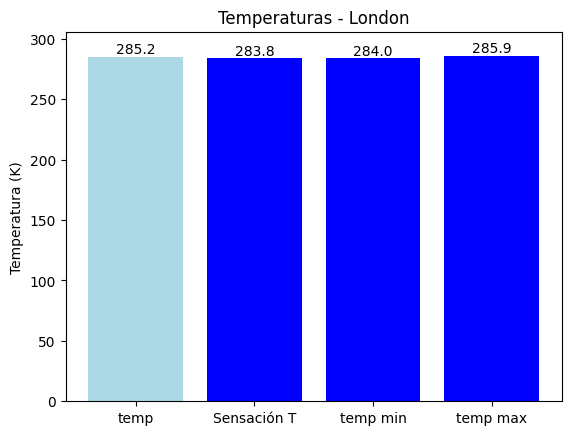

In [9]:
temps = [main['temp'], main['feels_like'], main['temp_min'], main['temp_max']]
labels = ["temp", "Sensación T", "temp min", "temp max"]

colors = ["lightblue", "blue", "blue", "blue"]

plt.figure()
bars = plt.bar(labels, temps, color=colors)
plt.ylabel("Temperatura (K)")
plt.ylim(0, max(temps) + 20)

# valores encima de cada barra
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, f"{y:.1f}",
             ha='center', va='bottom')

plt.title("Temperaturas - London")
plt.show()